# 9. Ray-traced voxels

`sylva.voxels` traces every pulse through a voxel grid and estimates the
attenuation coefficient λ of each voxel from how far pulses got, then plant area
density as λ / G. It follows AMAPVox and the rayvoxel tool; see the
[guide](../guide/voxels.md) for the estimators.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import Shots, voxels

Four scan positions around the plot, combined into one set of pulses. The echoes carry `classification` (2 ground, 4 leaf, 5 wood) and `tree_id`.

In [2]:
scene = synthetic.forest()
positions = [(3, 3), (17, 3), (3, 17), (17, 17), (10, 10)]
shots = Shots.concatenate([
    synthetic.scan(scene, origin=(x, y, synthetic.terrain_height(x, y) + 1.5), resolution_deg=0.2)
    for x, y in positions])
print(shots)

Shots(n_shots=5,850,000, n_echoes=402,651)


In [3]:
grid = voxels.ray_voxelize(
    shots, voxel_size=0.5, bounds=((0, 0, -0.5), (20, 20, 16.5)),
    ground_class=2, leaf_classes=[4], wood_classes=[5],
    attenuation=["fpl", "ppl"], laser="VZ-400", occlusion=True,
)
print(grid)
print("raw fields:", ", ".join(grid.fields[:12]), "...")

RayVoxelGrid(40x40x34 @ 0.5 m)
raw fields: num_hits, num_beams, num_beams_occluded, num_unbound_rays, num_miss_rays, num_hit_leaf, num_hit_wood, num_hit_plant, num_beams_weighted, path_length, path_length_sq, free_path_length ...


## What the pulses saw

`state` is 0 unobserved, 1 occluded (only reached behind a last echo), 2 empty, 3 filled. Arrays are `(nz, ny, nx)`.

{'unobserved': '0.0%', 'occluded': '0.0%', 'empty': '90.6%', 'filled': '9.4%'}


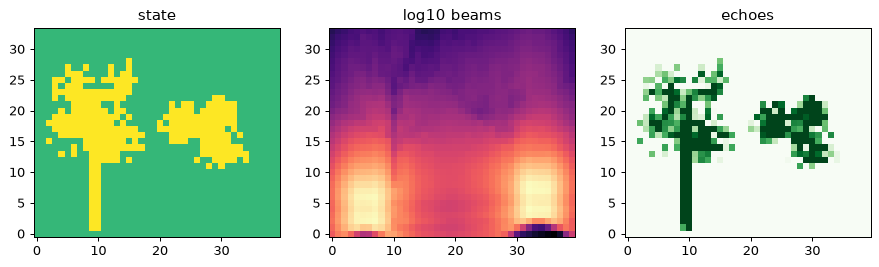

In [4]:
state = grid.state
names = ["unobserved", "occluded", "empty", "filled"]
print({n: f"{np.mean(state == i):.1%}" for i, n in enumerate(names)})
fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
j = 10                                        # the row of voxels at y = 5 m, through two trees
ax[0].imshow(state[:, j, :], origin="lower", cmap="viridis", vmin=0, vmax=3); ax[0].set_title("state")
ax[1].imshow(np.log10(grid.num_beams[:, j, :] + 1), origin="lower", cmap="magma"); ax[1].set_title("log10 beams")
ax[2].imshow(grid.num_hits[:, j, :], origin="lower", cmap="Greens", vmax=50); ax[2].set_title("echoes");

## Attenuation and area density

FPL and PPL agree where voxels are well sampled. Leaf and wood area density split λ by echo class; `transmittance` is the beam-section weighted gap probability. The scene's true leaf area is known. Expect the estimate to be of the right size but low: the pseudo-scanner only sees each leaf disc through its 12 points, so some pulses slip through leaves a real beam would hit.

PAI: 0.26  LAI: 0.19  true LAI of the scene: 0.3


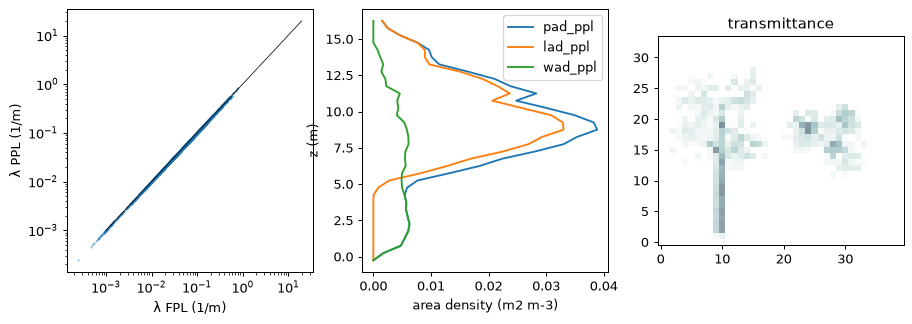

In [5]:
ok = (grid.num_beams >= 20) & (grid.num_hits > 0)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
ax[0].loglog(grid.attenuation_fpl[ok], grid.attenuation_ppl[ok], ".", ms=1.5, alpha=0.4)
ax[0].plot([1e-3, 20], [1e-3, 20], "k", lw=0.6); ax[0].set(xlabel="λ FPL (1/m)", ylabel="λ PPL (1/m)")
z = grid.z_levels() + 0.25
for name in ("pad_ppl", "lad_ppl", "wad_ppl"):
    ax[1].plot(grid.profile(name, min_beams=20), z, label=name)
ax[1].set(xlabel="area density (m2 m-3)", ylabel="z (m)"); ax[1].legend()
ax[2].imshow(grid.transmittance[:, j, :], origin="lower", cmap="bone", vmin=0, vmax=1); ax[2].set_title("transmittance")
print("PAI:", round(float(np.nansum(grid.profile("pad_ppl", min_beams=20)) * grid.voxel_size), 2),
      " LAI:", round(float(np.nansum(grid.profile("lad_ppl", min_beams=20)) * grid.voxel_size), 2),
      " true LAI of the scene:", round(synthetic.leaf_area(scene) / 20**2, 2))

## Leaf angles

With `inclination=True`, normals of the echoes give an inclination angle distribution per tree, and G is integrated over it and over the tree's beam zeniths instead of assuming a spherical distribution. The synthetic leaves are randomly oriented discs, so the result should be close to spherical with G ≈ 0.5.

tree 1: leaves spherical    G_leaf 0.50   wood erectophile  G_wood 0.47
tree 2: leaves spherical    G_leaf 0.50   wood erectophile  G_wood 0.50
tree 3: leaves spherical    G_leaf 0.50   wood erectophile  G_wood 0.47
tree 4: leaves spherical    G_leaf 0.50   wood erectophile  G_wood 0.48


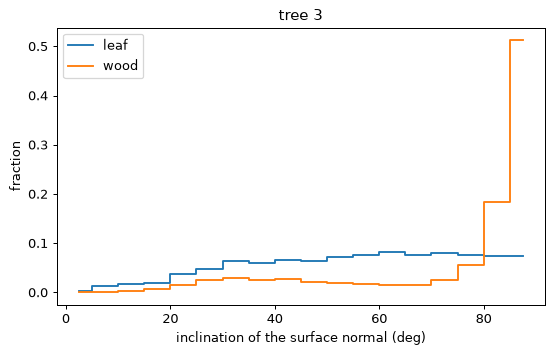

In [6]:
inc = voxels.ray_voxelize(shots, 0.5, ((0, 0, -0.5), (20, 20, 16.5)), ground_class=2,
                          leaf_classes=[4], wood_classes=[5], inclination=True)
for tid, t in inc.tree_iad.items():
    print(f"tree {tid}: leaves {t['liad_de_wit']:12s} G_leaf {t['g_leaf']:.2f}   wood {t['wiad_de_wit']:12s} G_wood {t['g_wood']:.2f}")
t = inc.tree_iad[3]
plt.step(np.degrees(t["bin_centres"]), t["liad"], where="mid", label="leaf")
plt.step(np.degrees(t["bin_centres"]), t["wiad"], where="mid", label="wood")
plt.gca().set(xlabel="inclination of the surface normal (deg)", ylabel="fraction", title="tree 3"); plt.legend();

## Wood volume, files and streaming

QSM cylinders can be rasterised into the same grid; `write` produces an AMAPVox `.vox` file or a text table; and a shots file is voxelised without loading it.

In [7]:
from sylva import qsm
tree3 = scene[scene.attrs["tree_id"] == 3]
model = qsm.build_qsm(tree3[tree3.attrs["classification"] == 5], base_xy=(8.0, 15.0))
grid.add_wood_volume(model)
print(f"wood volume in the grid {grid.wood_volume.sum():.3f} m3 of {model.total_volume:.3f} m3 in the QSM")

n = grid.write("plot.vox")
print(n, "voxels written;", open("plot.vox").read().split("\n")[6][:110], "...")

shots.save("plot.parquet")
streamed = voxels.ray_voxelize("plot.parquet", 0.5, ((0, 0, -0.5), (20, 20, 16.5)), ground_class=2)
print("streamed from file:", streamed, "- same hits:", int(streamed.num_hits.sum()) == int(grid.num_hits.sum()))

wood volume in the grid 1.141 m3 of 1.141 m3 in the QSM
54400 voxels written; i j k num_hits num_hit_plant free_path_length_plant free_path_length_leaf free_path_length_wood num_hit_leaf n ...


streamed from file: RayVoxelGrid(40x40x34 @ 0.5 m) - same hits: True
